# Logistic Regression


---
### 📋 Descripción del notebook

La **regresión logística** es el modelo de clasificación binaria más utilizado en banca: predice la *probabilidad* de que ocurra un evento (churn, impago, contratación) y clasifica en función de un umbral.

**Caso de uso:** predecir qué clientes de un banco van a abandonar el servicio (**churn**) en función de su perfil y comportamiento. Dataset de Kaggle con 10.000 clientes de un banco europeo.

**Lo que cubre este notebook:**
1. Exploración del dataset de churn
2. Preprocesado: eliminación de variables irrelevantes, encoding de categóricas
3. Escalado y partición train/test
4. Entrenamiento de `LogisticRegression`
5. Evaluación completa: matriz de confusión, classification report, ROC-AUC, Kappa, MCC
6. Importancia de variables mediante coeficientes


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Seaborn is a Python data visualization library based on matplotlib
import seaborn as sns
%matplotlib inline

Importaciones base. Las librerías de modelado (`sklearn`) se cargarán más adelante, justo donde se necesitan, para que el flujo pedagógico sea más claro.

####  0. Importamos los datos

##### El set de datos proviene de aquí: https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset

**RowNumber**: The sequential number assigned to each row in the dataset.  
**CustomerId**: A unique identifier for each customer.  
**Surname**: The surname of the customer.  
**CreditScore**: The credit score of the customer.  
**Geography**: The geographical location of the customer (e.g., country or region).  
**Gender**: The gender of the customer.  
**Age**: The age of the customer.  
**Tenure**: The number of years the customer has been with the bank.  
**Balance**: The account balance of the customer.  
**NumOfProducts**: The number of bank products the customer has.  
**HasCrCard**: Indicates whether the customer has a credit card (binary: yes/no).  
**IsActiveMember**: Indicates whether the customer is an active member (binary: yes/no).  
**EstimatedSalary**: The estimated salary of the customer.  
**Exited**: Indicates whether the customer has exited the bank (binary: yes/no).  

In [2]:
os.getcwd()

'c:\\Users\\tomas\\ML\\Master Data Science and AI\\04 Aprendizaje supervisado'

In [3]:
file='data\\Churn_Modelling.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

Cargamos el dataset `Churn_Modelling.csv`. Con `df.shape` vemos las dimensiones: **10.000 filas × 14 columnas**. Cada fila es un cliente; la variable objetivo es `Exited` (1 = abandonó el banco, 0 = sigue siendo cliente).

#### 1. Analizamos los datos

In [4]:
# Get the first five rows of DataFrame ad_data.
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Vista rápida de las primeras filas para familiarizarnos con el formato de los datos, los tipos de valores y si hay alguna anomalía visible a simple vista.

In [5]:
df.shape

(10000, 14)

Confirmamos la dimensión del dataset: 10.000 clientes y 14 variables. Es un tamaño adecuado para regresión logística sin necesidad de técnicas especiales de muestreo.

In [6]:
# Get a concise summary of DataFrame ad_data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


`df.info()` nos da de un vistazo:
- Los **tipos de dato** de cada columna (int64, float64, object)
- Si hay **valores nulos** (filas non-null)
- El consumo de memoria del DataFrame

Variables `object` como `Geography` y `Gender` necesitarán **encoding** antes de entrar al modelo.


In [7]:
# Get the statistical summary of the DataFrame ad_data.
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


`df.describe()` muestra estadísticos básicos de las variables numéricas: media, desviación típica, mínimo, máximo y percentiles.

Puntos a revisar:
- ¿Las escalas son muy distintas entre variables? (`Balance` en miles vs `HasCrCard` en 0/1) → necesitaremos **escalado**
- ¿Hay valores extremos (mínimos/máximos extraños)?
- ¿La media de `Exited` ≈ 0.20 confirma el desbalanceo del 20% / 80%?


Hay un 20% de clientes exited

**Desbalanceo de clases: dato clave.**

Con solo un 20% de churners, si el modelo predijera *siempre* que el cliente no se va, tendría un 80% de accuracy... sin haber aprendido nada útil. Por eso en clasificación desbalanceada usamos métricas más informativas: **Precision, Recall, F1, ROC-AUC, Kappa, MCC**.


#### 1.1 Chequeamos si hay valores nulos

In [8]:
# The isnull() method is used to check and manage NULL values in a data frame.
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Sin valores nulos: no es necesaria ninguna estrategia de imputación. Podemos proceder directamente al preprocesado de variables.

#### 1.2 Histogramas

In [9]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Surname', 'Geography', 'Gender']
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


La función `tipo_variables()` clasifica automáticamente las columnas del DataFrame en **numéricas** y **categóricas** según su dtype. Esto nos permite aplicar transformaciones distintas a cada grupo de forma sistemática, sin hardcodear nombres de columnas.

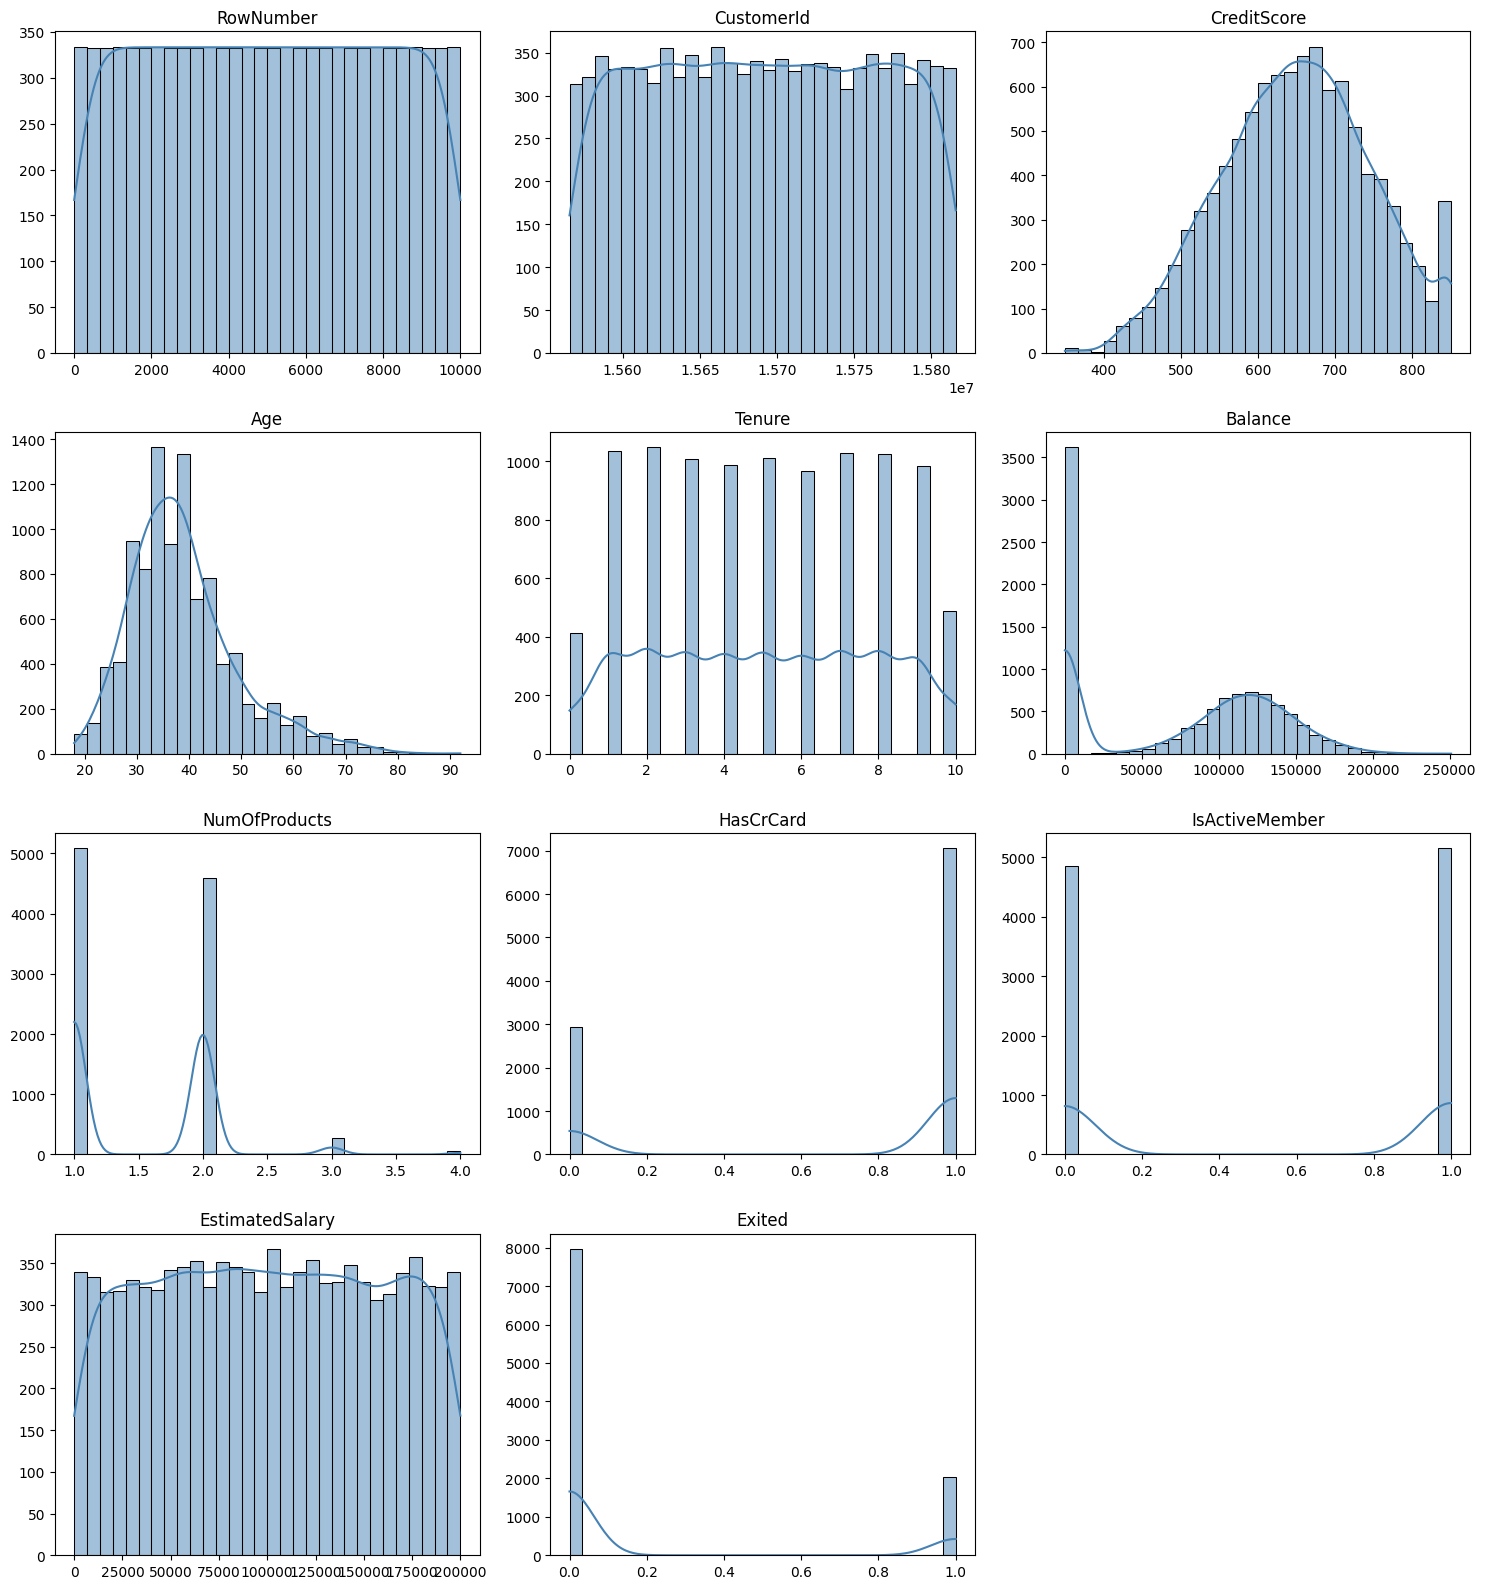

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Supongamos que tienes un DataFrame llamado df y una lista con las variables numéricas
# num_vbles = ['edad', 'glucosa', 'presion', 'colesterol', 'peso', 'altura', ...]

n = len(num_vbles)
cols = 3  # Número de columnas del grid
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*5, rows*4))  # Ajusta el tamaño según tu número de variables

for i, var in enumerate(num_vbles, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[var], bins=30, kde=True, color='steelblue')
    plt.title(var)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


Los histogramas con KDE nos permiten ver la **distribución** de cada variable numérica:
- Variables sesgadas → pueden beneficiarse de transformaciones (log, sqrt)
- Variables con rango muy distinto → confirma la necesidad de **StandardScaler** antes del modelo
- `Exited` (0/1) aparecerá como un histograma bimodal: refleja el desbalanceo 80/20


#### 2. Transformamos las variables

In [11]:
df_original = df

Guardamos una copia del DataFrame original antes de modificarlo. Buena práctica para poder volver al estado inicial si necesitamos depurar o explorar algo diferente.

**2.1 Eliminamos variables que no vamos a usar**  
El apellido tiene pinta de que va a ser una variable dispersa y no va a aportar al modelo

In [12]:
frecuencias = df['Surname'].value_counts()
frecuencias

Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Wells         1
Calzada       1
Gresswell     1
Aguirre       1
Morales       1
Name: count, Length: 2932, dtype: int64

`Surname` tiene muchos valores únicos y poca frecuencia por valor → es una variable con **alta cardinalidad** que difícilmente aportará poder predictivo al modelo y podría introducir ruido o sobreajuste si se codificara directamente.

`RowNumber` y `CustomerId` son identificadores técnicos sin relación causal con el churn: su presencia solo añadiría ruido.


In [13]:
df.shape

(10000, 14)

In [14]:
df = df.drop(columns=['Surname','RowNumber', 'CustomerId'])

In [15]:
df.shape

(10000, 11)

Confirmamos que el DataFrame ahora tiene **11 columnas** (las 14 originales menos `Surname`, `RowNumber` y `CustomerId`). Las variables que quedan son todas potencialmente informativas para predecir el churn.

**2.1 Transformamos las variables categoricas en dummies**

In [16]:
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Geography', 'Gender']
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


Volvemos a clasificar variables tras el drop. Las categóricas que quedan son `Geography` (3 valores: France, Germany, Spain) y `Gender` (2 valores: Male, Female). Ambas necesitan **encoding** antes de entrar al modelo.

In [17]:
from sklearn.preprocessing import OneHotEncoder
# Crear un objeto OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
#El parámetro sparse_output=False asegura que la salida sea un array denso 
#(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.
for i in cat_vbles:
    encoded_data = encoder.fit_transform(df[[i]])
    column_names = encoder.get_feature_names_out([i])
    encoded_df=pd.DataFrame(encoded_data, columns=column_names)
    df = pd.concat([df, encoded_df], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0


**One-Hot Encoding** transforma cada variable categórica en columnas binarias (0/1), una por categoría:

- `Geography` → `Geography_France`, `Geography_Germany`, `Geography_Spain`
- `Gender` → `Gender_Female`, `Gender_Male`

Parámetros usados:
- `sparse_output=False` → devuelve array denso (más fácil de convertir a DataFrame)

> ⚠️ **Dummy variable trap:** con regresión logística estándar se puede incluir todas las dummies (no es necesario descartar una como en OLS). Sin embargo, si usas regularización fuerte, puede ayudar eliminar una por variable para evitar colinealidad perfecta.


**Eliminamos las variables categoricas una vez las hemos convertido en dummies**  

In [18]:
df = df.drop(columns=cat_vbles)

Eliminamos las columnas categóricas originales (`Geography`, `Gender`) ahora que ya están codificadas como dummies. El DataFrame queda completamente numérico, listo para modelar.

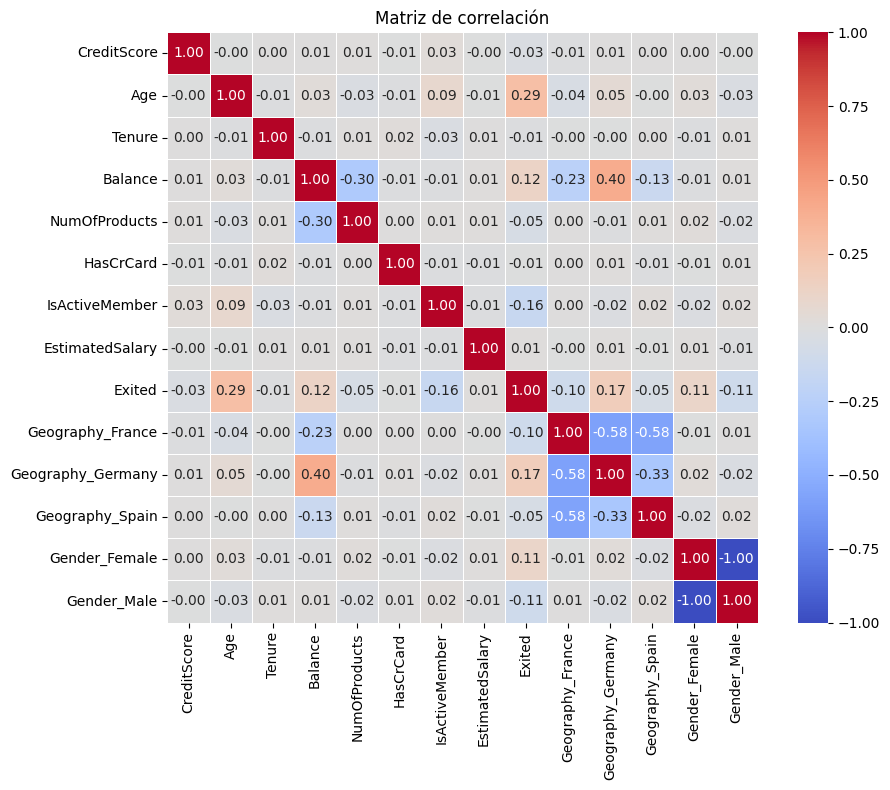

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,             # Muestra los coeficientes
    fmt=".2f",              # Formato de decimales
    cmap='coolwarm',         # Colormap apto para daltónicos: cividis
    square=True,
    linewidths=0.5,
    #linecolor='gray'
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


El heatmap con `annot=True` muestra los coeficientes de correlación exactos. En clasificación nos interesa especialmente la última fila/columna de `Exited`:

- Variables con correlación **positiva alta** con `Exited` → perfil de churner
- Variables con correlación **negativa alta** → perfil de cliente fiel

> 💡 La correlación de Pearson solo captura relaciones lineales. Un coeficiente bajo no significa necesariamente que la variable sea irrelevante: puede tener una relación no lineal con el churn.


####  3. Modelo: Logistic Regression

Básicamente es una regresión lineal con una función de activación al final que nos sirve para predecir una clase u otra. Sirve para clasificar: Ej: el cliente contrata el préstamos o no.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
frecuencias = df['Exited'].value_counts()
frecuencias

Exited
0    7963
1    2037
Name: count, dtype: int64

Verificamos la distribución de la variable objetivo antes de modelar. Con ~20% de churners (clase 1) y ~80% de no-churners (clase 0), el dataset está **moderadamente desbalanceado**.

Opciones si el desbalanceo fuera más severo:
- `class_weight='balanced'` en `LogisticRegression`
- Oversampling (SMOTE) o undersampling
- Ajuste del umbral de clasificación (no siempre 0.5 es el óptimo)


In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_X = StandardScaler()

X = df.drop(columns='Exited')
X_scaled = scaler_X.fit_transform(X)
y = df['Exited']

**Escalado con `StandardScaler`** (normalización z-score):

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Centra cada variable en 0 con desviación típica 1. La regresión logística usa un optimizador iterativo (L-BFGS por defecto) que **converge mucho más rápido y de forma más estable** cuando todas las variables están en la misma escala.

> ⚠️ El scaler se ajusta (`fit_transform`) solo sobre `X` (no sobre `X_train`). Idealmente debería ajustarse solo sobre `X_train` para evitar cualquier filtración de información del test. Tenerlo en cuenta para producción.


#### 3.1 Separamos en train y test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

Partición **67% train / 33% test** con `random_state=42` para reproducibilidad.

El 33% de test es algo mayor que el estándar 20-30%, lo que da una estimación de generalización más robusta en un dataset de 10.000 registros.


In [24]:
y_test.value_counts()

Exited
0    2657
1     643
Name: count, dtype: int64

Comprobamos que el conjunto de test mantiene la proporción aproximada 80/20 entre no-churners y churners. Si hubiera un desbalanceo muy pronunciado, usaríamos `stratify=y` en el `train_test_split`.

#### 3.2 Entrenamos el modelo

In [25]:
from sklearn.linear_model import LogisticRegression

Importamos `LogisticRegression`. Sus parámetros clave:
- `max_iter`: número máximo de iteraciones del optimizador (por defecto 100, aquí 1000 para garantizar convergencia)
- `C`: inverso de la fuerza de regularización. `C=0.01` es **regularización fuerte** → coeficientes comprimidos, modelo más simple y menos propenso a sobreajuste. `C=1.0` es el valor por defecto (regularización moderada).
- `solver`: algoritmo de optimización ('lbfgs' por defecto, eficiente para datasets medianos)


In [26]:
logmodel = LogisticRegression(max_iter=1000, C=0.01)
logmodel.fit(X_train,y_train)

c:\Users\tomas\ML\cluster\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.01, max_iter=1000)

El modelo ajusta los coeficientes $\beta$ minimizando la **log-loss** (entropía cruzada) con regularización L2:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right] + \frac{1}{2C}\sum_j \beta_j^2$$

La función sigmoide convierte la combinación lineal en una **probabilidad** entre 0 y 1:

$$\hat{p} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \ldots + \beta_k x_k)}}$$

Si $\hat{p} \geq 0.5$ → predice churn (clase 1); si $\hat{p} < 0.5$ → predice no-churn (clase 0).


####  4. Evaluación del modelo

In [27]:
# Use predict() function to predict values for the testing data.
predictions = logmodel.predict(X_test)

`predict()` aplica el umbral de 0.5 sobre las probabilidades internas y devuelve la **clase predicha** (0 o 1) para cada cliente del test.

Si quisiéramos las probabilidades brutas (útil para la curva ROC o para ajustar el umbral), usaríamos `predict_proba()`.


#### 4.1 Confusion matrix

In [28]:
from sklearn.metrics import confusion_matrix

---
#### La Matriz de Confusión

La herramienta más completa para entender el comportamiento de un clasificador binario. Para nuestro caso (1 = churn, 0 = no churn):

|  | Predicho: Churn | Predicho: No Churn |
|---|---|---|
| **Real: Churn** | **TP** (Verdadero Positivo) | **FN** (Falso Negativo) |
| **Real: No Churn** | **FP** (Falso Positivo) | **TN** (Verdadero Negativo) |

- **TP**: correctamente identificados como churners → los que queremos maximizar
- **FN**: churners que el modelo NO detectó → el error más costoso en churn (cliente perdido)
- **FP**: no-churners clasificados como churners → falsa alarma (coste de retención innecesaria)
- **TN**: correctamente identificados como no-churners


In [29]:
cm = confusion_matrix(y_test, predictions, labels=[1, 0])

# Mostrar la matriz de confusión
print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[ 106  537]
 [  68 2589]]


El heatmap de la matriz de confusión hace más fácil la lectura visual: los números en la diagonal son los aciertos (TP y TN); fuera de la diagonal están los errores (FP y FN).

> 💡 En un modelo de churn bancario el **FN** (no detectar un churner) es más costoso que el FP (llamar innecesariamente a un cliente fiel). Si queremos reducir FN, podemos bajar el umbral de clasificación por debajo de 0.5.


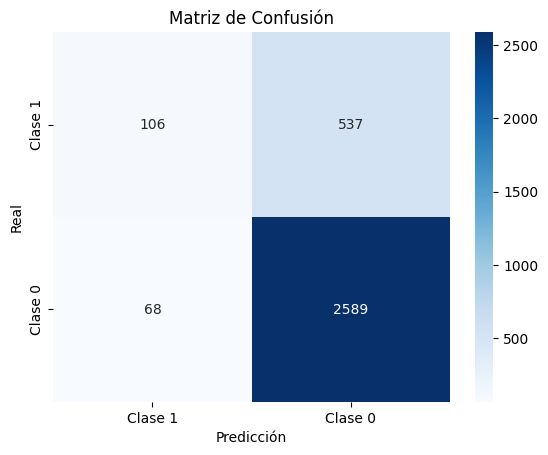

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#### 4.2 Clasification report 

In [31]:
# The classification_report function builds a text report showing the main classification metrics.
from sklearn.metrics import classification_report

---
#### Classification Report: métricas por clase

| Métrica | Fórmula | Qué mide |
|---|---|---|
| **Precision** | TP / (TP + FP) | De los que predijo como churners, ¿cuántos realmente lo son? |
| **Recall** | TP / (TP + FN) | De todos los churners reales, ¿cuántos detectó? |
| **F1-score** | 2·P·R / (P+R) | Media armónica entre Precision y Recall |
| **Support** | — | Número de casos reales de cada clase |

**Accuracy** global puede ser engañosa con clases desbalanceadas: un modelo que siempre predice 0 tiene 80% de accuracy pero 0% de Recall en la clase churn.


In [32]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.83      0.97      0.90      2657
           1       0.61      0.16      0.26       643

    accuracy                           0.82      3300
   macro avg       0.72      0.57      0.58      3300
weighted avg       0.79      0.82      0.77      3300



---
#### Curva ROC-AUC

La curva ROC representa el **trade-off entre TPR y FPR** para todos los posibles umbrales de clasificación (no solo 0.5):

- **TPR** (True Positive Rate = Recall): eje Y — proporción de churners detectados
- **FPR** (False Positive Rate): eje X — proporción de no-churners clasificados erróneamente

El **AUC** (Área bajo la curva) resume la curva en un único número:
- **AUC = 1.0** → clasificador perfecto
- **AUC = 0.5** → clasificador aleatorio (línea diagonal)
- **AUC > 0.7** → modelo útil; **> 0.8** → bueno; **> 0.9** → excelente

> 💡 El AUC es independiente del umbral de clasificación, lo que lo hace muy útil para **comparar modelos** entre sí.


**4.3 Curva ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**

ROC-AUC: 0.76


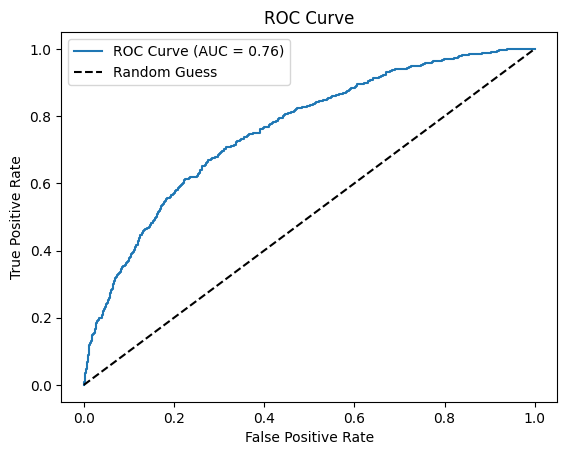

In [33]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Calculamos primero las probabilidades de ser 1 ó 0
pred_proba = logmodel.predict_proba(X_test)[:, 1]

# Calcular ROC-AUC
roc_auc = roc_auc_score(y_test, pred_proba) # Ojo en la curva ROC hay que pasarle las probabilidades de que pertenezca a la clas 1
print(f"ROC-AUC: {roc_auc:.2f}")

# Calcular los valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, pred_proba)

# Graficar la curva ROC
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

---
#### Índice Kappa de Cohen

Complementa a la accuracy ajustando por el **acuerdo que ocurriría por azar** con este desbalanceo de clases:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Donde $p_o$ es el acuerdo observado y $p_e$ el acuerdo esperado por azar.

Interpretación orientativa:

| Kappa | Acuerdo |
|---|---|
| < 0.20 | Pobre |
| 0.21 – 0.40 | Leve |
| 0.41 – 0.60 | Moderado |
| 0.61 – 0.80 | Sustancial |
| > 0.80 | Casi perfecto |


#### 4.4 Kappa del modelo
El **índice Kappa (o Kappa de Cohen)** mide el grado de acuerdo entre las predicciones de un modelo y los valores reales, ajustando por el acuerdo que podría ocurrir por azar.  
El valor del índice Kappa oscila entre: 
* 1: Acuerdo perfecto entre las predicciones y las etiquetas reales.
* 0: Acuerdo puramente aleatorio (sin relación real entre predicciones y etiquetas).
* Valores negativos: Indican un desacuerdo peor que el azar.  

Este índice es útil cuando las clases están desbalanceadas o quieres evaluar la consistencia del modelo más allá de la precisión global.


In [34]:
from sklearn.metrics import cohen_kappa_score

In [35]:
# Calcular el índice Kappa
kappa = cohen_kappa_score(y_test,predictions)

# Mostrar el Kappa
print(f"Índice Kappa: {kappa:.2f}")

Índice Kappa: 0.19


---
#### MCC (Matthews Correlation Coefficient)

Considera los cuatro cuadrantes de la matriz de confusión de forma simétrica. Es especialmente robusto con **clases desbalanceadas**:

$$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

- **MCC = +1** → predicción perfecta
- **MCC = 0** → predicción no mejor que el azar
- **MCC = -1** → desacuerdo total (invierte siempre las clases)

> El MCC y el Kappa son mucho más informativos que la accuracy cuando hay desbalanceo de clases. En banca se usan con frecuencia en modelos de scoring crediticio y churn para comparar modelos de forma justa.


#### 4.5 MCC (Matthews Correlation Coefficient)

El **índice de correlación de Mattews** Mide la calidad de la clasificación considerando todas las categorías de la matriz de confusión.  
Útil cuando: Quieres una métrica equilibrada incluso para datos desbalanceados.  
Rango: De -1 (desempeño malo) a 1 (desempeño perfecto).


In [36]:
from sklearn.metrics import matthews_corrcoef
# Calcular el MCC
mcc = matthews_corrcoef(y_test, predictions)

# Mostrar el resultado
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

Matthews Correlation Coefficient (MCC): 0.25


#### 4.6 Importancia de variables

In [37]:
import pandas as pd
import numpy as np

# Extraer los coeficientes
coeficientes = logmodel.coef_[0]  # Es un array 1D si es binario

# Emparejarlos con los nombres de las variables
importancia = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': coeficientes
})

# Ordenarlos por importancia absoluta
importancia['abs'] = np.abs(importancia['coeficiente'])
importancia = importancia.sort_values(by='abs', ascending=False)

print(importancia[['variable', 'coeficiente']])


             variable   coeficiente
6      IsActiveMember -7.871928e-01
12        Gender_Male -4.413105e-01
10    Geography_Spain -3.430524e-01
8    Geography_France -3.279544e-01
9   Geography_Germany  2.599502e-01
4       NumOfProducts -1.063903e-01
5           HasCrCard -1.046524e-01
1                 Age  5.686514e-02
2              Tenure -3.740861e-02
11      Gender_Female  3.025359e-02
0         CreditScore -2.943189e-03
3             Balance  2.504152e-06
7     EstimatedSalary -7.344740e-07


**Importancia de variables mediante coeficientes**

En regresión logística, el coeficiente $\beta_j$ indica el cambio en el **log-odds** de churn por cada unidad de aumento en $x_j$ (manteniendo el resto constante).

- Coeficiente **positivo alto** → esa variable aumenta la probabilidad de churn
- Coeficiente **negativo alto** → esa variable reduce la probabilidad de churn
- Coeficiente ≈ **0** → la variable tiene poco efecto sobre la predicción

> ⚠️ Con regularización `C=0.01` los coeficientes están comprimidos. Con `C` más alto serían más grandes en valor absoluto pero el ranking relativo debería mantenerse.


C:\Users\tomas\AppData\Local\Temp\ipykernel_28796\3061593526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia, x='coeficiente', y='variable', palette='coolwarm')


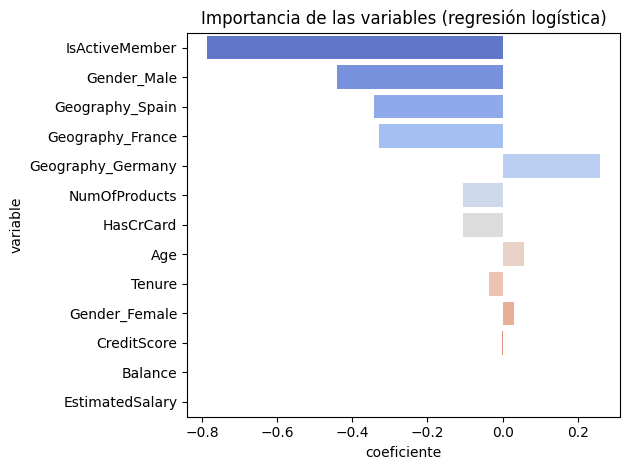

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=importancia, x='coeficiente', y='variable', palette='coolwarm')
plt.title('Importancia de las variables (regresión logística)')
plt.tight_layout()
plt.show()

El barplot permite identificar de un vistazo las variables más relevantes para el modelo:

- Las barras más largas (positivas o negativas) corresponden a las variables que más peso tienen en la decisión
- El color frío indica coeficiente negativo (reduce la probabilidad de churn); el color cálido, coeficiente positivo (aumenta la probabilidad)

---
> **Conclusión del notebook:**
> La regresión logística ofrece un modelo interpretable y robusto para clasificación binaria.
> En un problema de churn bancario, las métricas clave no son la accuracy sino el **Recall** de la clase churn (¿cuántos churners detectamos?) y el **AUC-ROC** (calidad global del scoring).
> El siguiente paso natural sería explorar modelos más potentes (Random Forest, XGBoost) y comparar sus métricas con este baseline logístico.
